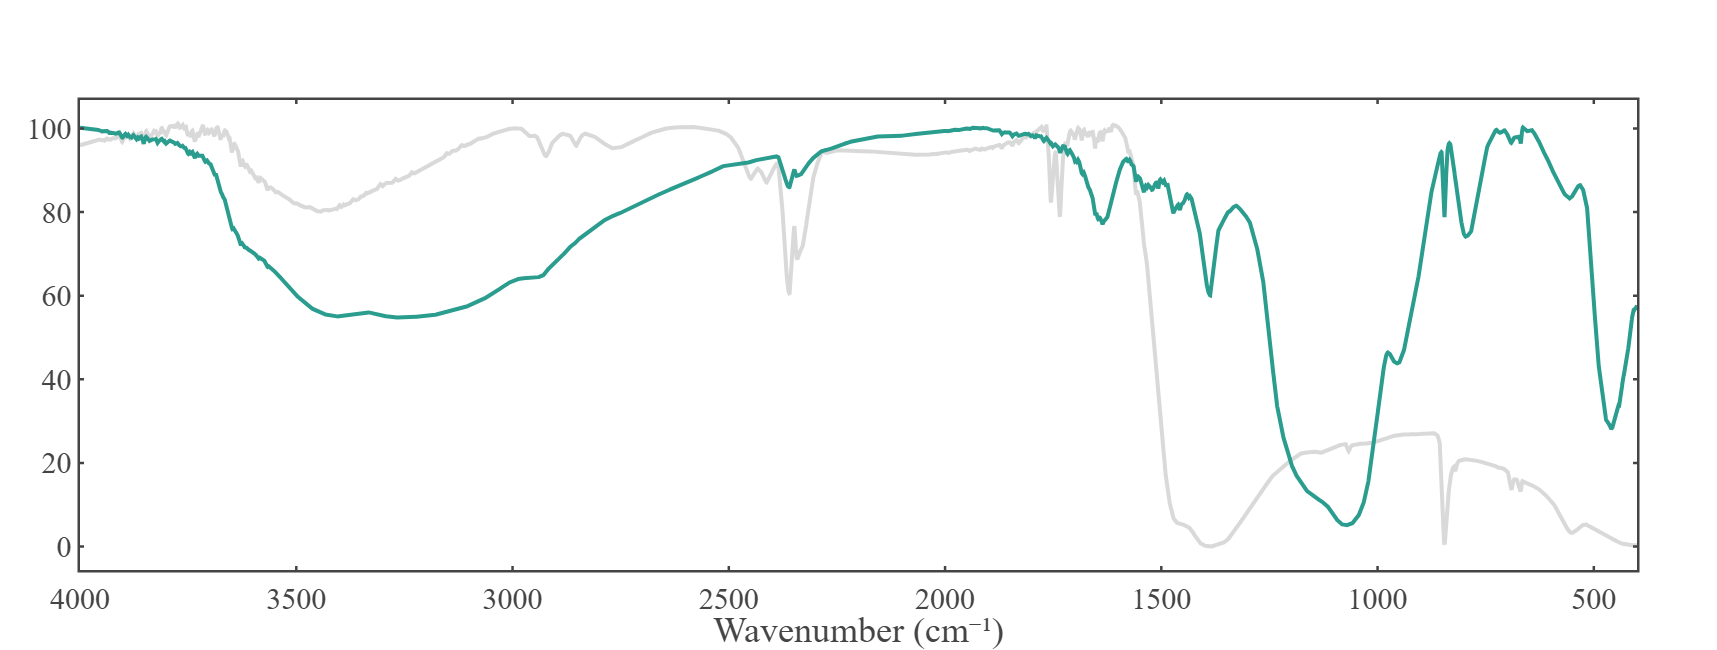

Saved figure: D:\Atanu\NaBiF4_PL_analysis\NaBiF4_PL_analysis\NaBiF4_PL_analysis\figures in paper\FTIR_comparison.png


In [24]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import os

# ============================================================
# --- File paths ---
# ============================================================
sample_file = r"D:\Atanu\NaBiF4_PL_analysis\NaBiF4_PL_analysis\NaBiF4_PL_analysis\FTIR\Atanu_doped sample.tsv"
ref_file = r"D:\Atanu\NaBiF4_PL_analysis\NaBiF4_PL_analysis\NaBiF4_PL_analysis\FTIR\Atanu_ref.tsv"

# ============================================================
# --- Load TSV Data ---
# Assumes 2 columns: Wavenumber  Intensity/Absorbance
# ============================================================
def load_tsv(path):
    df = pd.read_csv(path, sep='\t', header=None)
    x = df.iloc[:, 0].values   # Wavenumber (cm⁻¹)
    y = df.iloc[:, 1].values   # Intensity / Transmittance / Absorbance
    return x, y

wn_sample, I_sample = load_tsv(sample_file)
wn_ref, I_ref = load_tsv(ref_file)

# ============================================================
# --- Custom Plotly Template ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'font': {
        'family': 'mathjax',
        'size': 30,
    }
}

# ===========================================================
# --- Plot ---
# ===========================================================
fig = go.Figure()



fig.add_trace(go.Scatter(
    x=wn_ref, y=I_ref,
    mode='lines',
    name='Reference',
    line=dict(width=4, color='rgba(180,180,180,0.5)'),
    showlegend=False
))


fig.add_trace(go.Scatter(
    x=wn_sample, y=I_sample,
    mode='lines',
    name='NaBiF4 Doped Sample',
    line=dict(width=4, color='#2a9d8f'),
    showlegend=False
))


# ===========================================================
# --- Layout Settings ---
# ===========================================================
fig.update_layout(
    template=fig_template,
    width=800,
    height=650,
    xaxis_title="Wavenumber (cm⁻¹)",
    # yaxis_title="Transmittance (%)",
    xaxis=dict(autorange="reversed"),   # FTIR convention
)

fig.show()

# ============================================================
# --- Save figure ---
# ============================================================
output_fig_folder = r"D:\Atanu\NaBiF4_PL_analysis\NaBiF4_PL_analysis\NaBiF4_PL_analysis\figures in paper"
os.makedirs(output_fig_folder, exist_ok=True)

out_path = os.path.join(output_fig_folder, "FTIR_comparison.png")
pio.write_image(fig, out_path, scale=4)

print("Saved figure:", out_path)